# Laboratorio — Regresión lineal: consumo eléctrico

**Pregunta:** ¿podemos estimar el consumo eléctrico (`Consumption`, MW) a partir de producción por fuente y calendario? Cada fila representa una observación fechada. La fecha determina la partición cronológica. Esta tarea supone que las variables de producción estarán disponibles al momento de predecir; en un pronóstico futuro real habría que sustituirlas por información conocida entonces o por rezagos.

**Ruta:** problema → datos → exploración en entrenamiento → preparación → baseline → modelo → selección (cuando procede) → evaluación fuera de muestra → residuos → coeficientes → límites.


## Objetivos de aprendizaje

- Justificar la partición cronológica y evitar que validación o test informen el ajuste.
- Comparar un baseline con una regresión y explicar MAE, RMSE y $R^2$.
- Leer residuos, coeficientes y su dependencia de la escala de las variables.
- Analizar colinealidad, heterocedasticidad y alternativas sencillas de selección de variables.


## Fundamento

El modelo lineal representa $\hat y=\beta_0+\sum_j\beta_jx_j$. Mínimos cuadrados minimiza la suma de errores cuadrados; la lectura inferencial de los coeficientes requiere supuestos adicionales y cuidado con colinealidad y autocorrelación. La penalización no se aplica al intercepto en los estimadores utilizados.


## 1. Configuración

Imports agrupados al inicio. Usaremos modelos simples de scikit-learn y mantendremos visibles los ajustes, predicciones y métricas.

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Fuente y calidad de los datos

Conservamos la fuente de los notebooks originales y ofrecemos una ruta relativa cuando se ejecutan fuera del proyecto. La fuente debe contener `DateTime`, `Consumption` y las ocho variables de producción. Revisamos tipo, orden cronológico, duplicados y faltantes antes de decidir su tratamiento.

In [ ]:
project_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve().parent.parent,
]

candidate_paths = []
for root in project_roots:
    candidate_paths.extend([
        root / 'machine_learning' / 'data' / 'external' / 'electricity_consumption_and_production.csv',
        root / 'data' / 'external' / 'electricity_consumption_and_production.csv',
    ])
try:
    from ml_course.data import get_data_path
    fallback_path = get_data_path('electricity_consumption_and_production.csv', category='external')
    candidate_paths.append(Path(fallback_path))
except (ModuleNotFoundError, RuntimeError):
    pass

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        'No se encontró el CSV del proyecto. Se buscó en:\n' +
        '\n'.join(str(p) for p in candidate_paths)
    )

print(f'Usando dataset: {csv_path}')
raw = pd.read_csv(csv_path)
raw['DateTime'] = pd.to_datetime(raw['DateTime'], errors='raise')
raw = raw.sort_values('DateTime').set_index('DateTime')
ENERGY_FEATURES = ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
TARGET = 'Consumption'
required = [TARGET] + ENERGY_FEATURES
missing_columns = sorted(set(required) - set(raw.columns))
if missing_columns:
    raise ValueError(f'Faltan columnas requeridas: {missing_columns}')
print('Forma:', raw.shape, 'Duplicados de fecha:', raw.index.duplicated().sum())
print('Faltantes requeridos:', raw[required].isna().sum().to_dict())
display(raw[required].head())
display(raw[required].describe().round(2))

## 3. Variables originales y candidatas de ingeniería

Separamos mediciones continuas de indicadores discretos. Las fuentes de generación y `Production` son continuas; hora, día de la semana y mes son categorías de calendario. Más adelante compararemos el calendario original con las categorías agrupadas por perfil de consumo, además de una proporción de renovables y un término cuadrático de producción. Hora, día y mes se conservan para crear los grupos, pero no entran directamente al modelo principal. Son hipótesis de representación, no mejoras garantizadas.


In [110]:
model_df = raw[required].copy()
model_df['hour'] = model_df.index.hour
model_df['day_of_week'] = model_df.index.dayofweek
model_df['month'] = model_df.index.month
model_df['year'] = model_df.index.year
BASE_NUMERIC = ENERGY_FEATURES + ['year']
ENGINEERED_NUMERIC = ['production_squared', 'renewable_share']
NUMERIC = BASE_NUMERIC + ENGINEERED_NUMERIC
CALENDAR_DISCRETE = ['month']
GROUPED_FEATURES = ['hour_group', 'weekday_group', 'month_group']
CATEGORICAL = GROUPED_FEATURES
model_df = model_df[[TARGET] + BASE_NUMERIC + ['hour', 'day_of_week'] + CALENDAR_DISCRETE]
print('Continuas originales:', BASE_NUMERIC)
print('Calendario discreto:', ['hour', 'day_of_week'] + CALENDAR_DISCRETE)
print('Candidatas derivadas:', ENGINEERED_NUMERIC)


Continuas originales: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'year']
Calendario discreto: ['hour', 'day_of_week', 'month']
Candidatas derivadas: ['production_squared', 'renewable_share']


## 4. Partición cronológica

El 70 % inicial entrena, el 15 % siguiente valida decisiones y el 15 % final estima el error una vez congelada la configuración. No barajamos filas; medimos la capacidad de generalizar hacia fechas posteriores. La definición de predictores contemporáneos corresponde a estimación/nowcasting.

In [111]:
n = len(model_df)
train_end, validation_end = int(.70*n), int(.85*n)
assert train_end > 20 and validation_end > train_end and n > validation_end, 'Se requieren suficientes fechas en cada partición.'
train_raw = model_df.iloc[:train_end].copy()
val_raw = model_df.iloc[train_end:validation_end].copy()
test_raw = model_df.iloc[validation_end:].copy()
for name, part in [('train',train_raw), ('validation',val_raw), ('test',test_raw)]:
    print(name, len(part), part.index.min(), '→', part.index.max())


train 43967 2019-01-01 00:00:00 → 2024-01-06 18:00:00
validation 9421 2024-01-06 19:00:00 → 2025-02-09 21:00:00
test 9422 2025-02-09 22:00:00 → 2026-03-14 23:00:00


## 5. Análisis exploratorio de datos (solo entrenamiento)

Antes de transformar o ajustar, examinamos `Consumption` y sus asociaciones con las variables predictoras usando exclusivamente `train_raw`. Comenzamos con correlaciones y la serie temporal para reconocer tendencia, estacionalidad, valores extremos y posibles cambios de régimen. Las correlaciones marginales no son coeficientes del modelo ni implican causalidad.

También resumiremos media y desviación estándar de la respuesta por categoría y agruparemos perfiles similares. Como es una transformación supervisada, solo entrenamiento aporta las estadísticas.


,corr_consumption_train
Production,0.703
Oil and Gas,0.501
Coal,0.481
Biomass,0.406
Hydroelectric,0.284
Solar,0.136
Nuclear,0.132
Wind,0.085


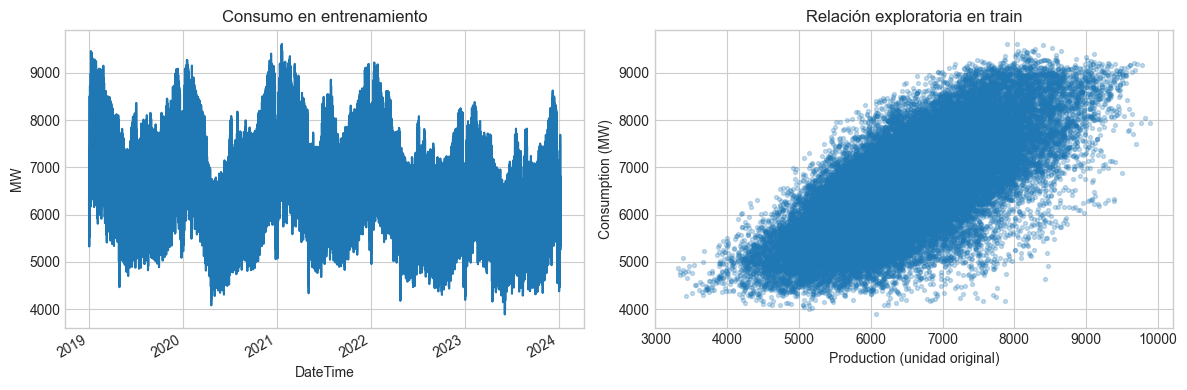

In [112]:
train_corr = train_raw[[TARGET]+ENERGY_FEATURES].corr()[TARGET].drop(TARGET)
display(train_corr.sort_values(key=np.abs, ascending=False).to_frame('corr_consumption_train').round(3))
fig, axes = plt.subplots(1, 2, figsize=(12,4))
train_raw[TARGET].plot(ax=axes[0], title='Consumo en entrenamiento', ylabel='MW')
axes[1].scatter(train_raw['Production'], train_raw[TARGET], alpha=.25, s=8)
axes[1].set(xlabel='Production (unidad original)', ylabel='Consumption (MW)', title='Relación exploratoria en train')
plt.tight_layout();plt.show()


### Distribución de la variable objetivo por categorías de calendario

La hora, el día de la semana y el mes son variables discretas. Un boxplot por categoría muestra mediana, dispersión y valores extremos de `Consumption` en MW; el conteo permite detectar categorías poco observadas. Comparamos el patrón sin asumir que una diferencia de cajas se mantendrá en fechas futuras. Si train cubre pocos meses, esa comparación mensual es limitada.


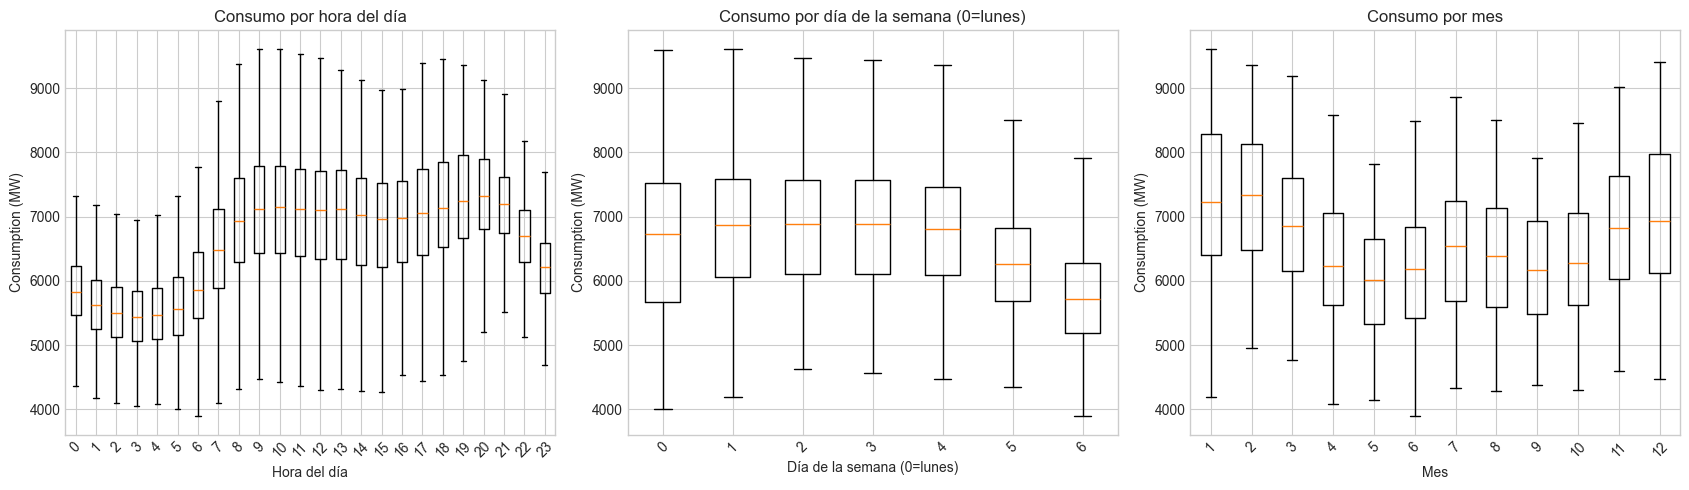

Observaciones por hour:


,n
hour,
0,1832
1,1832
2,1832
3,1836
4,1832
5,1832
6,1832
7,1832
8,1832


Observaciones por day_of_week:


,n
day_of_week,
0,6264
1,6288
2,6288
3,6288
4,6288
5,6283
6,6268


Observaciones por month:


,n
month,
1,3859
2,3384
3,3715
4,3600
5,3720
6,3600
7,3720
8,3720
9,3600


In [113]:
calendar_features = [('hour','Hora del día'), ('day_of_week','Día de la semana (0=lunes)'), ('month','Mes')]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (feature, label) in zip(axes, calendar_features):
    groups = train_raw.groupby(feature)[TARGET]
    levels = sorted(train_raw[feature].dropna().unique())
    samples = [groups.get_group(level).dropna().to_numpy() for level in levels]
    ax.boxplot(samples, tick_labels=[str(level) for level in levels], showfliers=False)
    ax.set(xlabel=label, ylabel='Consumption (MW)', title=f'Consumo por {label.lower()}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout();plt.show()
for feature, _ in calendar_features:
    print(f'Observaciones por {feature}:')
    display(train_raw[feature].value_counts().sort_index().rename('n').to_frame())


**Lectura:** compara medianas y amplitud intercuartílica. Las cajas con pocos registros o meses ausentes no permiten inferir estacionalidad anual; `showfliers=False` evita saturar el panel, pero no elimina las observaciones del análisis.

### Relación entre el objetivo y variables numéricas

Un diagrama de dispersión por predictor ayuda a detectar curvatura, heterocedasticidad, saturación y puntos influyentes antes de elegir transformaciones. Las ocho mediciones energéticas comparten posibles relaciones físicas; `year` se muestra aparte como tendencia temporal discreta y no como evidencia de una relación lineal estable.


### Agrupación supervisada de categorías por media y dispersión

Para hora, día de la semana y mes calculamos **media**, **desviación estándar** y **conteo** de `Consumption` exclusivamente en entrenamiento. Estandarizamos media/desviación de los niveles con al menos cinco observaciones y aplicamos K-Means a esos perfiles, con hasta tres grupos por variable; si hay menos perfiles distintos, reducimos K. El número de grupos es una decisión exploratoria, no un óptimo validado. Las etiquetas son arbitrarias.


In [114]:
GROUP_SOURCES = {'hour':'hour_group', 'day_of_week':'weekday_group', 'month':'month_group'}
MIN_GROUP_COUNT = 5
group_maps = {}
group_summaries = {}
for source, feature in GROUP_SOURCES.items():
    summary = train_raw.groupby(source)[TARGET].agg(['mean', 'std', 'count'])
    summary['std'] = summary['std'].fillna(0)
    eligible = summary.loc[summary['count'] >= MIN_GROUP_COUNT, ['mean','std']]
    if len(eligible) < 2:
        labels = np.zeros(len(eligible), dtype=int)
    else:
        group_scaler = StandardScaler()
        values = group_scaler.fit_transform(eligible)
        distinct_profiles = len(np.unique(np.round(values, 8), axis=0))
        group_model = KMeans(n_clusters=min(3, distinct_profiles), n_init=20, random_state=RANDOM_STATE)
        labels = group_model.fit_predict(values)
    group_maps[source] = dict(zip(eligible.index.tolist(), labels.tolist()))
    summary['group'] = pd.Series(group_maps[source]).reindex(summary.index).fillna(-1).astype(int)
    group_summaries[source] = summary
    print(f'Perfiles de {source}: -1 indica categoría poco representada')
    display(summary.round(2))


Perfiles de hour: -1 indica categoría poco representada


,mean,std,count,group
hour,,,,
0,5862.85,556.41,1832,1
1,5653.04,555.44,1832,1
2,5535.67,560.63,1832,1
3,5482.30,566.68,1836,1
4,5512.60,578.94,1832,1
5,5620.38,626.38,1832,1
6,5939.26,747.42,1832,1
7,6499.34,912.75,1832,0
8,6931.39,1005.84,1832,0


Perfiles de day_of_week: -1 indica categoría poco representada


,mean,std,count,group
day_of_week,,,,
0,6631.77,1183.85,6264,2
1,6844.45,1033.13,6288,0
2,6875.18,1005.61,6288,0
3,6874.66,993.68,6288,0
4,6815.36,974.84,6288,0
5,6302.86,813.49,6283,1
6,5770.68,764.74,6268,1


Perfiles de month: -1 indica categoría poco representada


,mean,std,count,group
month,,,,
1,7268.20,1171.09,3859,2
2,7306.72,968.27,3384,1
3,6880.57,925.89,3715,1
4,6300.16,937.15,3600,0
5,5988.72,798.46,3720,0
6,6150.92,879.08,3600,0
7,6487.79,919.26,3720,0
8,6353.12,895.13,3720,0
9,6163.16,841.57,3600,0


### Inspección gráfica de grupos de categorías

Cada punto representa una categoría, ubicado por su consumo medio y desviación estándar; el color distingue la agrupación. Categorías próximas tienen perfiles descriptivos parecidos, aunque puedan ocupar posiciones lejanas en el calendario. Compara los grupos con los boxplots anteriores y revisa sus tamaños antes de modelar.


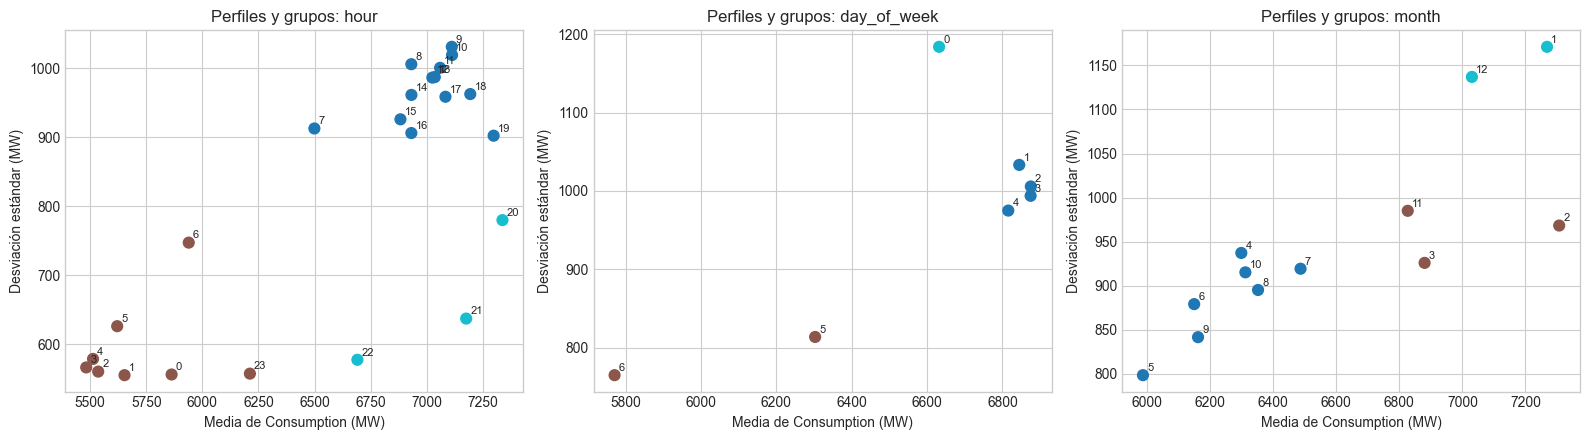

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (source, summary) in zip(axes, group_summaries.items()):
    ax.scatter(summary['mean'], summary['std'], c=summary['group'], cmap='tab10', s=60)
    for category, row in summary.iterrows():
        ax.annotate(str(category), (row['mean'],row['std']), xytext=(3,3), textcoords='offset points', fontsize=8)
    ax.set(xlabel='Media de Consumption (MW)', ylabel='Desviación estándar (MW)',
           title=f'Perfiles y grupos: {source}')
plt.tight_layout();plt.show()


**Lectura:** horas cercanas o días consecutivos no tienen que pertenecer al mismo grupo: aquí prima la semejanza de media y dispersión, no la continuidad temporal. La desviación estándar describe variabilidad entre registros, no incertidumbre de la media. Con pocos meses observados no se justifican grupos estacionales generalizables.


### Distribuciones de `Consumption` por grupo de categorías

Para `hour_group`, `weekday_group` y `month_group` comparamos las observaciones individuales: los **boxplots** muestran mediana, rango intercuartílico y valores extremos; los **KDE** comparan la forma y superposición de las distribuciones. Cada fila de gráficos corresponde a una agrupación distinta. Se usa únicamente `train_raw` y sus mapas de grupos entrenados; el código `-1` representa categorías con pocos registros.


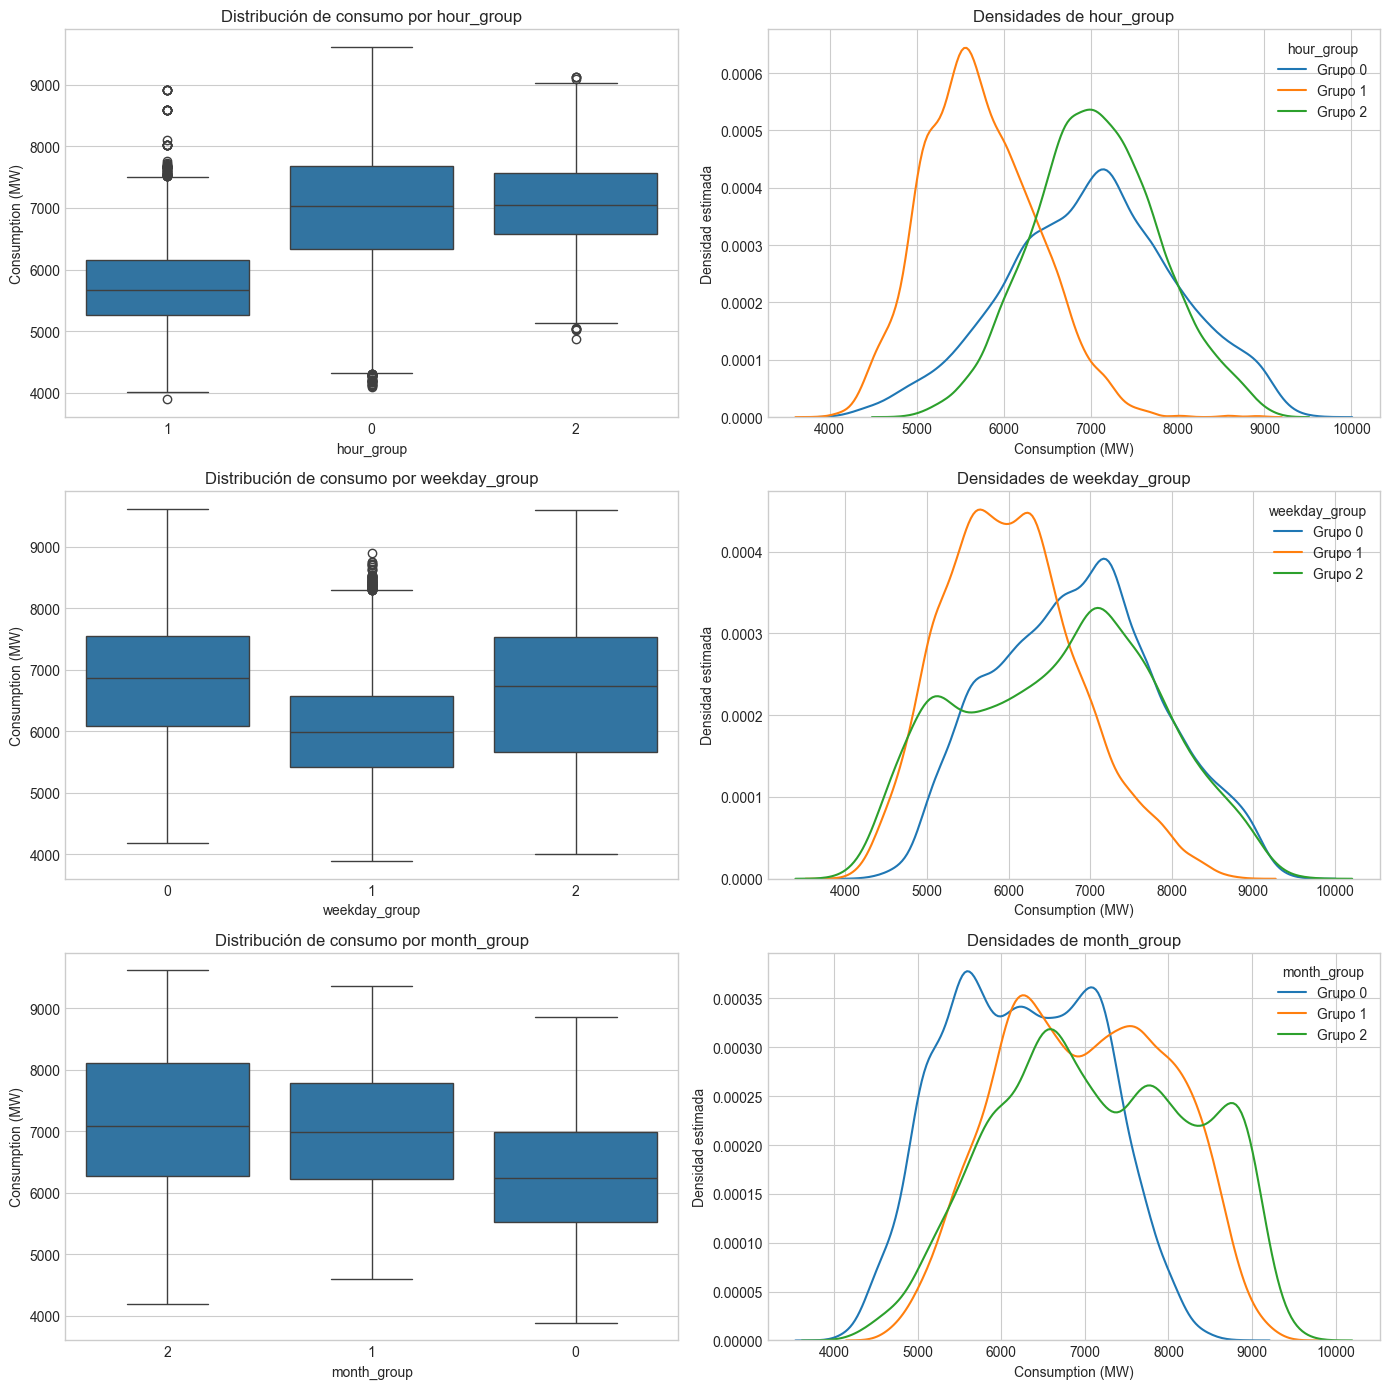

In [116]:
grouped_train_eda = train_raw[[TARGET] + list(GROUP_SOURCES)].copy()
for source, feature in GROUP_SOURCES.items():
    grouped_train_eda[feature] = grouped_train_eda[source].map(group_maps[source]).fillna(-1).astype(int).astype(str)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for row, feature in enumerate(GROUPED_FEATURES):
    sns.boxplot(data=grouped_train_eda, x=feature, y=TARGET, ax=axes[row, 0], showfliers=True)
    axes[row, 0].set(xlabel=feature, ylabel='Consumption (MW)', title=f'Distribución de consumo por {feature}')
    for group, part in grouped_train_eda.groupby(feature):
        values = part[TARGET].dropna()
        if len(values) >= 3 and values.nunique() >= 3:
            sns.kdeplot(x=values, ax=axes[row, 1], label=f'Grupo {group}', warn_singular=False)
    axes[row, 1].set(xlabel='Consumption (MW)', ylabel='Densidad estimada', title=f'Densidades de {feature}')
    if axes[row, 1].lines:
        axes[row, 1].legend(title=feature)
plt.tight_layout();plt.show()


**Interpretación:** contrasta tamaño de las cajas, colas y solapamiento de densidades con el conteo de categorías y observaciones. Cada KDE se normaliza dentro de su grupo: su altura no representa el número de registros. Un grupo pequeño puede carecer de curva si no hay datos suficientes. **La separación en train es parcialmente esperable**, porque los grupos se formaron con medias y desviaciones de esta misma respuesta; no la uses como evidencia de ganancia predictiva. Para eso compara el RMSE en validation y repite ventanas temporales.


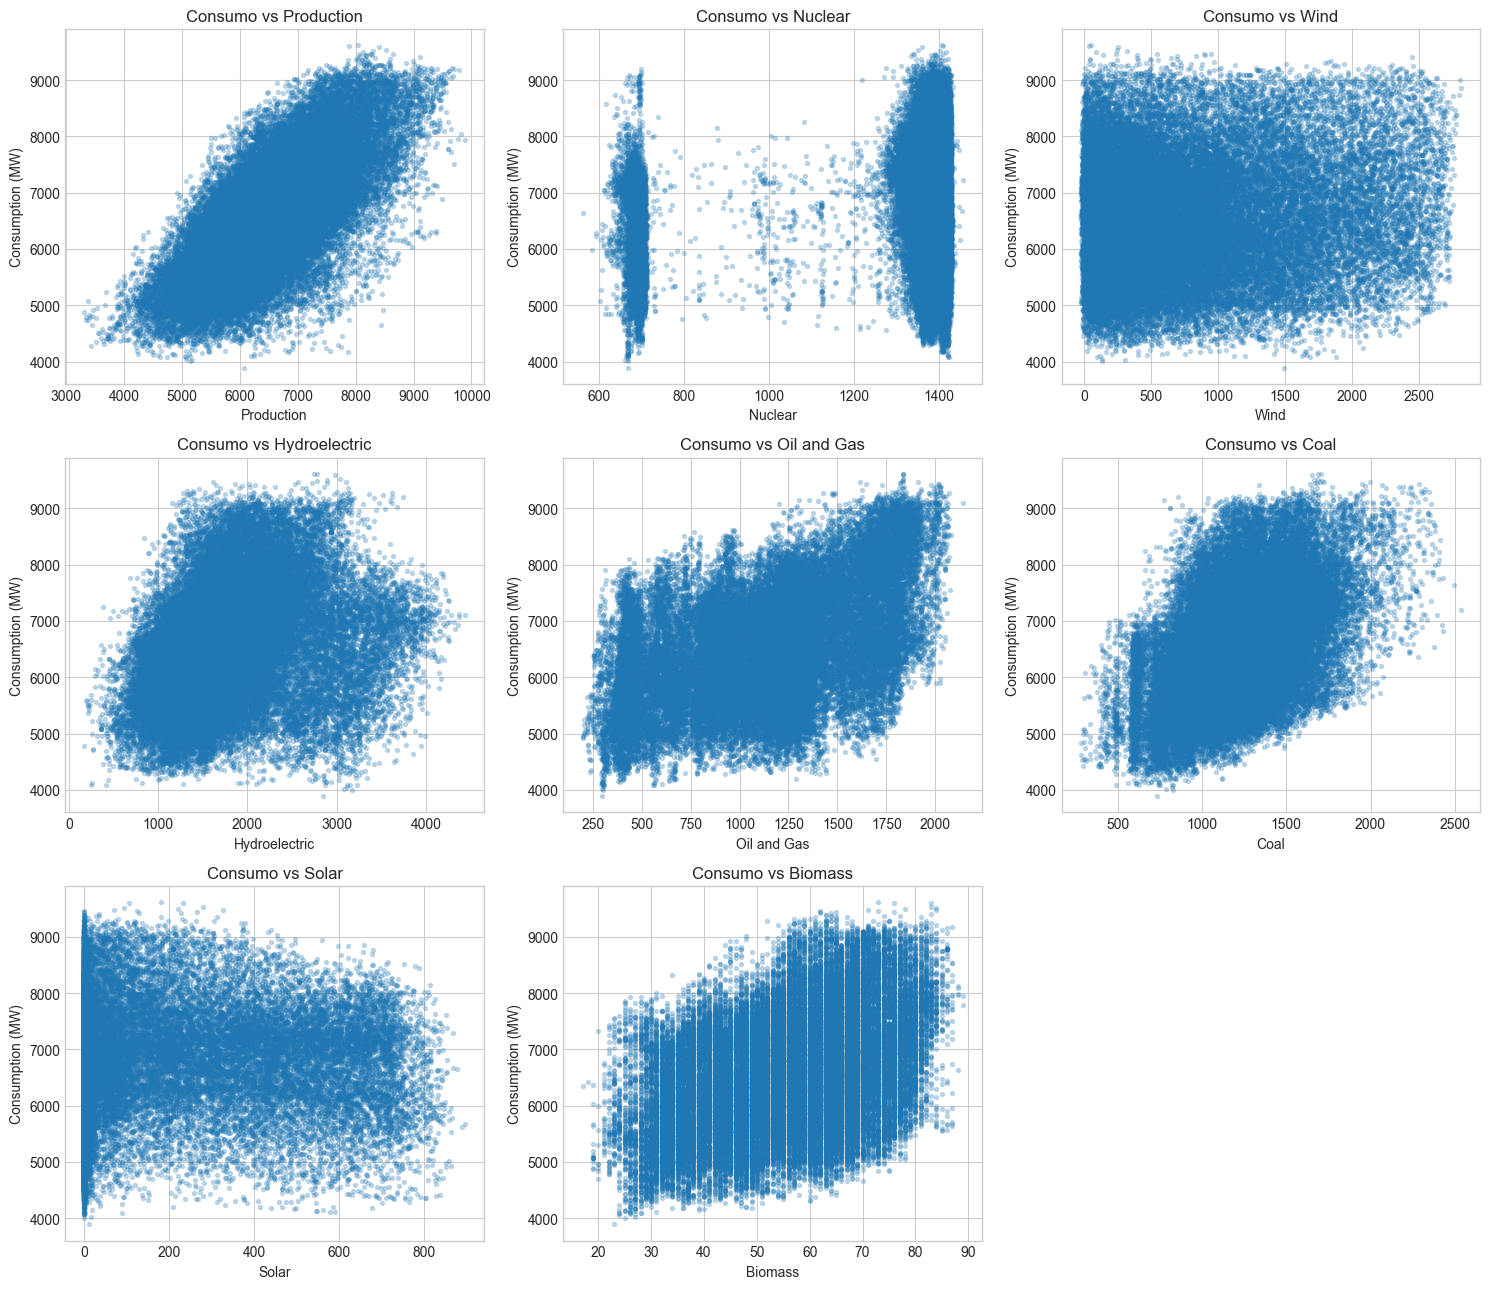

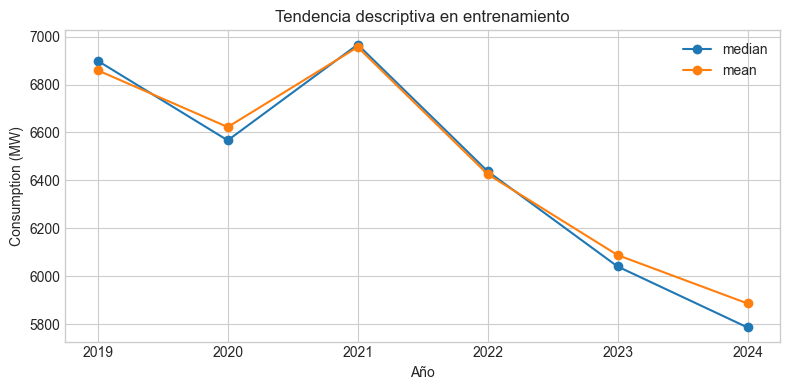

In [117]:
numeric_eda = ENERGY_FEATURES
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, feature in zip(axes.flat, numeric_eda):
    ax.scatter(train_raw[feature], train_raw[TARGET], alpha=.25, s=8)
    ax.set(xlabel=feature, ylabel='Consumption (MW)', title=f'Consumo vs {feature}')
for ax in list(axes.flat)[len(numeric_eda):]:
    ax.axis('off')
plt.tight_layout();plt.show()
fig, ax = plt.subplots(figsize=(8, 4))
train_raw.groupby('year')[TARGET].agg(['median','mean']).plot(marker='o', ax=ax)
ax.set(xlabel='Año', ylabel='Consumption (MW)', title='Tendencia descriptiva en entrenamiento')
plt.tight_layout();plt.show()


**Interpretación para feature engineering:** la dispersión puede motivar `Production²` o transformaciones de asimetría; patrones por hora o día pueden motivar ciclos o dummies. Solo la evaluación en validation indica si una representación mejora el error en fechas posteriores. Las variables de producción contemporáneas deben estar disponibles al hacer la predicción.


## 6. Feature engineering — variables continuas

Primero imputamos los predictores originales con medianas de train. Luego proponemos: `Production²` para curvatura, proporción de fuentes renovables para composición. La proporción usa la suma no negativa de las fuentes como denominador; si es cero, asignamos 0. Estas variables solo utilizan información predictora de la misma fila, no `Consumption`. El término cuadrático es sensible a extremos: la comparación en validation y el análisis de residuos deben juzgar su utilidad.

Las tres categorías agrupadas se construyen con mapas estimados exclusivamente en train. Una categoría con menos de cinco registros o no observada en train recibe el código `-1`; su comportamiento futuro es incierto.


In [118]:
for name, part in [('train',train_raw), ('validation',val_raw), ('test',test_raw)]:
    if part[TARGET].isna().any():
        raise ValueError(f'El objetivo tiene faltantes en {name}; define el alcance de la evaluación antes de continuar.')
numeric_medians = train_raw[BASE_NUMERIC].median()
category_modes = train_raw[CALENDAR_DISCRETE].mode().iloc[0]
train_ready = train_raw.copy(); val_ready = val_raw.copy(); test_ready = test_raw.copy()
for part in [train_ready, val_ready, test_ready]:
    part[BASE_NUMERIC] = part[BASE_NUMERIC].fillna(numeric_medians)
    part[CALENDAR_DISCRETE] = part[CALENDAR_DISCRETE].fillna(category_modes)
    for source, feature in GROUP_SOURCES.items():
        part[feature] = part[source].map(group_maps[source]).fillna(-1).astype(int).astype(str)
    part['production_squared'] = part['Production'] ** 2
    renewable = part[['Wind','Hydroelectric','Solar','Biomass']].clip(lower=0).sum(axis=1)
    source_total = part[ENERGY_FEATURES[1:]].clip(lower=0).sum(axis=1)
    part['renewable_share'] = renewable.div(source_total.replace(0,np.nan)).fillna(0)
print('Faltantes tras ingeniería en train:', int(train_ready[[TARGET]+NUMERIC+CATEGORICAL].isna().sum().sum()))
display(train_ready[ENGINEERED_NUMERIC].describe().round(3))


Faltantes tras ingeniería en train: 0


,production_squared,renewable_share
count,4.396700e+04,43967.000
mean,4.317078e+07,0.433
std,1.312518e+07,0.102
min,1.098922e+07,0.138
25%,3.351252e+07,0.362
50%,4.137062e+07,0.428
75%,5.109390e+07,0.497
max,9.773300e+07,0.761


## 7. Feature engineering — grupos discretos y escala

El modelo principal utiliza **exclusivamente** `hour_group`, `weekday_group` y `month_group` para representar el calendario. Los valores originales `hour`, `day_of_week` y `month` solo sirven para calcular los mapas de grupos y para el experimento comparativo; no se incluyen como predictores adicionales. Codificamos los tres grupos con one-hot, aprendiendo categorías solo en train, y estandarizamos las variables continuas con estadísticas de train. Los identificadores de grupo son arbitrarios: las dummies representan pertenencia, no un orden de consumo. Un grupo nuevo o poco observado recibe `-1`.


In [119]:
try:
    encoder = OneHotEncoder(handle_unknown='ignore', drop=None, sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', drop=None, sparse=False)
encoder.fit(train_ready[CATEGORICAL])
encoded_names = encoder.get_feature_names_out(CATEGORICAL).tolist()
assert list(encoder.feature_names_in_) == GROUPED_FEATURES
print('Calendario usado por el modelo:', GROUPED_FEATURES)
scaler = StandardScaler()
scaler.fit(train_ready[NUMERIC])
X_train_num = pd.DataFrame(scaler.transform(train_ready[NUMERIC]), columns=NUMERIC, index=train_ready.index)
X_val_num = pd.DataFrame(scaler.transform(val_ready[NUMERIC]), columns=NUMERIC, index=val_ready.index)
X_test_num = pd.DataFrame(scaler.transform(test_ready[NUMERIC]), columns=NUMERIC, index=test_ready.index)
X_train_cat = pd.DataFrame(encoder.transform(train_ready[CATEGORICAL]), columns=encoded_names, index=train_ready.index)
X_val_cat = pd.DataFrame(encoder.transform(val_ready[CATEGORICAL]), columns=encoded_names, index=val_ready.index)
X_test_cat = pd.DataFrame(encoder.transform(test_ready[CATEGORICAL]), columns=encoded_names, index=test_ready.index)
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val = pd.concat([X_val_num, X_val_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)
y_train, y_val, y_test = train_ready[TARGET], val_ready[TARGET], test_ready[TARGET]
print('Dimensiones:', X_train.shape, X_val.shape, X_test.shape)


Calendario usado por el modelo: ['hour_group', 'weekday_group', 'month_group']
Dimensiones: (43967, 20) (9421, 20) (9422, 20)


### Evaluación del reemplazo de categorías en validation

Comparamos tres diseños OLS ajustados solo con train: (1) variables originales y calendario desagrupado, (2) las mismas variables continuas derivadas del modelo final con calendario desagrupado, y (3) esas variables continuas con calendario **agrupado en lugar del original**. La diferencia entre (2) y (3) evalúa el reemplazo categórico en validation; el test no participa. Los mapas de grupos provienen de la respuesta de train, por lo que la evaluación en train puede ser optimista.


,representación,features,RMSE_validation
0,Original + categorías sin agrupar,49,716.376
1,Continuas nuevas + sin agrupar,51,710.532
2,Continuas nuevas + grupos,20,732.609


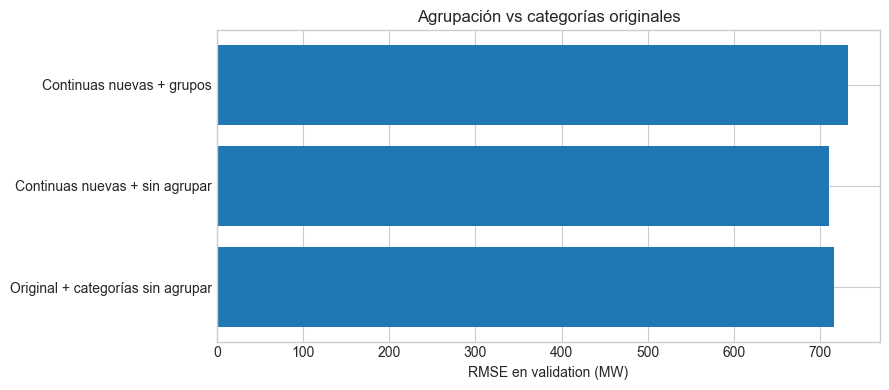

In [120]:
original_calendar = ['hour', 'day_of_week', 'month']
try:
    original_encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
except TypeError:
    original_encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse=False)
original_encoder.fit(train_ready[original_calendar])
original_scaler = StandardScaler()
original_scaler.fit(train_ready[BASE_NUMERIC])
original_train = np.column_stack([original_scaler.transform(train_ready[BASE_NUMERIC]), original_encoder.transform(train_ready[original_calendar])])
original_val = np.column_stack([original_scaler.transform(val_ready[BASE_NUMERIC]), original_encoder.transform(val_ready[original_calendar])])
continuous_original_train = np.column_stack([X_train[NUMERIC].to_numpy(), original_encoder.transform(train_ready[original_calendar])])
continuous_original_val = np.column_stack([X_val[NUMERIC].to_numpy(), original_encoder.transform(val_ready[original_calendar])])
original_ols = LinearRegression()
original_ols.fit(original_train, y_train)
continuous_original_ols = LinearRegression()
continuous_original_ols.fit(continuous_original_train, y_train)
grouped_ols = LinearRegression()
grouped_ols.fit(X_train, y_train)
representation_results = pd.DataFrame([
    {'representación':'Original + categorías sin agrupar', 'features':original_train.shape[1], 'RMSE_validation':np.sqrt(mean_squared_error(y_val, original_ols.predict(original_val)))},
    {'representación':'Continuas nuevas + sin agrupar', 'features':continuous_original_train.shape[1], 'RMSE_validation':np.sqrt(mean_squared_error(y_val, continuous_original_ols.predict(continuous_original_val)))},
    {'representación':'Continuas nuevas + grupos', 'features':X_train.shape[1], 'RMSE_validation':np.sqrt(mean_squared_error(y_val, grouped_ols.predict(X_val)))},
])
display(representation_results.round(3))
fig, ax = plt.subplots(figsize=(9,4))
ax.barh(representation_results['representación'], representation_results['RMSE_validation'])
ax.set(xlabel='RMSE en validation (MW)', title='Agrupación vs categorías originales')
plt.tight_layout();plt.show()


**Interpretación:** la diferencia entre las dos últimas filas estima el efecto de **reemplazar** las categorías originales por sus grupos, manteniendo las variables continuas. Un menor RMSE en validation sugiere utilidad en este período, pero hay que repetir la comparación en otras ventanas. Los grupos no garantizan continuidad horaria ni cobertura de meses futuros.


### Transformaciones adicionales para experimentar

| Tipo | Candidata | Hipótesis y condición |
|---|---|---|
| Continua | `log1p` o Yeo–Johnson en fuentes con fuerte asimetría | Puede reducir influencia de extremos; se debe comprobar distribución, ceros y signos **solo en train**. Ajustar Yeo–Johnson dentro de cada fold. |
| Continua | Interacciones entre fuentes o producción × hora | Podrían capturar cambios en la relación consumo–generación según composición o período; introducen colinealidad y requieren regularización. |
| Temporal | Rezagos de consumo/producción y medias móviles | Son candidatos para **forecast** si solo usan valores conocidos antes del instante objetivo. Aplicar `shift` previo a `rolling`, definir horizonte y descartar filas iniciales sin historial. |
| Discreta | Codificación cíclica de hora/día, festivos, fin de semana o estación | Podrían captar regímenes no descritos por hora/día/mes; requieren calendario y codificación derivada solo de la fecha conocida. |
| Objetivo | `log1p(Consumption)` si es no negativo y asimétrico | Puede estabilizar varianza; comparar errores **tras** volver a MW con `expm1` y estudiar el sesgo de retransformación. |

Estas son hipótesis, no resultados observados. Para medir el efecto de cada una, realiza una ablación individual dentro de train/validation y repite ventanas temporales. En particular, una variable contemporánea de producción puede no estar disponible en un pronóstico futuro aunque mejore la estimación del consumo del mismo período.


## 8. Baseline y referencia sin regularización

El promedio de train es un punto de comparación mínimo; la regresión ordinaria muestra cuánto aporta la forma lineal. Se ajustan ambos exclusivamente con train.

In [121]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
ols = LinearRegression()
ols.fit(X_train, y_train)
baseline_val = baseline.predict(X_val)
ols_val = ols.predict(X_val)
print('RMSE validation baseline:', round(np.sqrt(mean_squared_error(y_val, baseline_val)), 3))
print('RMSE validation OLS:', round(np.sqrt(mean_squared_error(y_val, ols_val)), 3))


RMSE validation baseline: 1063.878
RMSE validation OLS: 732.609


## 9. Ajuste principal y coeficientes

`fit` estima intercepto y pendientes. Con `Production` y fuentes correlacionadas, los coeficientes individuales pueden variar mucho aunque el error agregado sea aceptable. Los ordenamos por magnitud para describir, sin atribuir causalidad.

In [122]:
model = LinearRegression()
model.fit(X_train, y_train)
coef_table = pd.Series(model.coef_, index=X_train.columns, name='coeficiente').sort_values(key=np.abs, ascending=False)
display(coef_table.head(15).round(3))


Production           -686.064
hour_group_1         -624.169
production_squared    549.512
Oil and Gas           491.776
Coal                  366.849
hour_group_0          325.747
renewable_share       325.704
hour_group_2          298.423
weekday_group_1      -271.886
Hydroelectric         219.931
Nuclear               209.967
weekday_group_0       167.902
Biomass               167.333
year                 -153.573
weekday_group_2       103.984
Name: coeficiente, dtype: float64

## 10. Selección exploratoria de variables

Como ejercicio de selección, evaluamos un conjunto pequeño de variables numéricas: las cuatro con mayor correlación absoluta en train y las dummies de calendario. Este filtro usa train; validation permite comparar con el modelo completo. No se vuelve a escoger tras mirar test.

In [123]:
selected_energy = train_corr.abs().nlargest(4).index.tolist()
selected_columns = selected_energy + ['year'] + ENGINEERED_NUMERIC + encoded_names
subset_model = LinearRegression()
subset_model.fit(X_train[selected_columns], y_train)
subset_val = subset_model.predict(X_val[selected_columns])
selection_results = pd.DataFrame([
    {'modelo':'Completo','features':X_train.shape[1], 'RMSE_validation':np.sqrt(mean_squared_error(y_val, model.predict(X_val)))},
    {'modelo':'Filtro train','features':len(selected_columns), 'RMSE_validation':np.sqrt(mean_squared_error(y_val, subset_val))},
])
display(selection_results.round(3))
chosen_features = selected_columns if selection_results.loc[1,'RMSE_validation'] < selection_results.loc[0,'RMSE_validation'] else X_train.columns.tolist()
final_model = LinearRegression()
final_model.fit(X_train[chosen_features], y_train)
print('Variables retenidas:', len(chosen_features))


,modelo,features,RMSE_validation
0,Completo,20,732.609
1,Filtro train,16,721.815


Variables retenidas: 16


### Comparación de Best Subset, Forward y Backward

Conservamos los tres experimentos del cuaderno original en un conjunto acotado de **cuatro predictores energéticos**, dejando fijos el año y las dummies. Best Subset prueba todas las combinaciones; Forward agrega una variable por paso y Backward elimina una por paso. Cada ajuste y RMSE en validation es visible. **Reutilizar validation para muchas decisiones puede sobreajustarlo**: estos resultados sirven para comparar métodos, y el test se reserva para la configuración principal ya seleccionada.

In [124]:
from itertools import combinations
pool = train_corr.abs().nlargest(4).index.tolist()
fixed = ['year'] + ENGINEERED_NUMERIC + encoded_names
subset_rows = []
for size in range(1, len(pool)+1):
    for group in combinations(pool, size):
        cols = fixed + list(group)
        candidate = LinearRegression()
        candidate.fit(X_train[cols], y_train)
        pred = candidate.predict(X_val[cols])
        subset_rows.append({'features': group, 'n': size, 'RMSE_val': np.sqrt(mean_squared_error(y_val, pred))})
subset_results = pd.DataFrame(subset_rows).sort_values('RMSE_val')
display(subset_results.head(8).round(3))


,features,n,RMSE_val
7,"(Oil and Gas, Coal)",2,677.633
10,"(Production, Oil and Gas, Coal)",3,678.929
2,"(Coal,)",1,680.881
5,"(Production, Coal)",2,690.069
1,"(Oil and Gas,)",1,701.274
4,"(Production, Oil and Gas)",2,714.402
0,"(Production,)",1,715.778
13,"(Oil and Gas, Coal, Biomass)",3,721.172


**Lectura:** identifica si agregar una variable mejora RMSE lo suficiente para justificarla. Compara la combinación elegida con la correlación individual; una variable puede ser útil en conjunto aunque su correlación marginal sea menor.

In [125]:
forward_selected = []
forward_rows = []
while len(forward_selected) < len(pool):
    alternatives = []
    for feature in pool:
        if feature not in forward_selected:
            cols = fixed + forward_selected + [feature]
            candidate = LinearRegression()
            candidate.fit(X_train[cols], y_train)
            error = np.sqrt(mean_squared_error(y_val, candidate.predict(X_val[cols])))
            alternatives.append((error, feature))
    best_error, added = min(alternatives)
    forward_selected.append(added)
    forward_rows.append({'paso':len(forward_selected), 'variable_agregada':added, 'RMSE_val':best_error})
display(pd.DataFrame(forward_rows).round(3))


,paso,variable_agregada,RMSE_val
0,1,Coal,680.881
1,2,Oil and Gas,677.633
2,3,Production,678.929
3,4,Biomass,721.815


In [126]:
backward_selected = pool.copy()
backward_rows = []
while len(backward_selected) > 1:
    alternatives = []
    for removed in backward_selected:
        remaining = [feature for feature in backward_selected if feature != removed]
        cols = fixed + remaining
        candidate = LinearRegression()
        candidate.fit(X_train[cols], y_train)
        error = np.sqrt(mean_squared_error(y_val, candidate.predict(X_val[cols])))
        alternatives.append((error, removed, remaining))
    best_error, removed, backward_selected = min(alternatives)
    backward_rows.append({'variables_restantes':len(backward_selected), 'eliminada':removed, 'RMSE_val':best_error})
display(pd.DataFrame(backward_rows).round(3))


,variables_restantes,eliminada,RMSE_val
0,3,Biomass,678.929
1,2,Production,677.633
2,1,Oil and Gas,680.881


**Comparación:** Best Subset explora exhaustivamente este pool pequeño; Forward y Backward recorren solo algunas rutas y pueden llegar a conjuntos distintos. Ninguno demuestra que una feature sea causal o estable fuera de muestra.

### Bootstrap por bloques de coeficientes

Para mostrar incertidumbre en una serie temporal, remuestreamos **bloques consecutivos de 24 filas** de train en lugar de filas independientes. Reajustamos la configuración principal ya elegida y mostramos intervalos percentiles descriptivos; la longitud del bloque y el cambio de régimen afectan estos intervalos. No los interpretamos como inferencia causal.

In [127]:
rng = np.random.default_rng(RANDOM_STATE)
block_length = min(24, max(2, len(X_train)//10))
bootstrap_coefs = []
for repetition in range(100):
    sampled = []
    while len(sampled) < len(X_train):
        start = rng.integers(0, len(X_train)-block_length+1)
        sampled.extend(range(start, start+block_length))
    sampled = sampled[:len(X_train)]
    boot_model = LinearRegression()
    boot_model.fit(X_train.iloc[sampled][chosen_features], y_train.iloc[sampled])
    bootstrap_coefs.append(boot_model.coef_)
coef_samples = pd.DataFrame(bootstrap_coefs, columns=chosen_features)
top_coefficients = pd.Series(final_model.coef_, index=chosen_features).abs().nlargest(8).index
intervals = coef_samples[top_coefficients].quantile([.025,.5,.975]).T
intervals.columns = ['p2.5','mediana','p97.5']
display(intervals.round(3))


,p2.5,mediana,p97.5
hour_group_1,-682.104,-667.997,-656.772
hour_group_2,343.402,349.172,357.993
hour_group_0,310.518,318.144,331.169
weekday_group_1,-313.067,-289.273,-262.054
production_squared,122.798,231.680,350.027
Oil and Gas,174.972,203.427,231.180
Coal,171.894,189.226,213.993
weekday_group_0,151.786,179.137,197.743


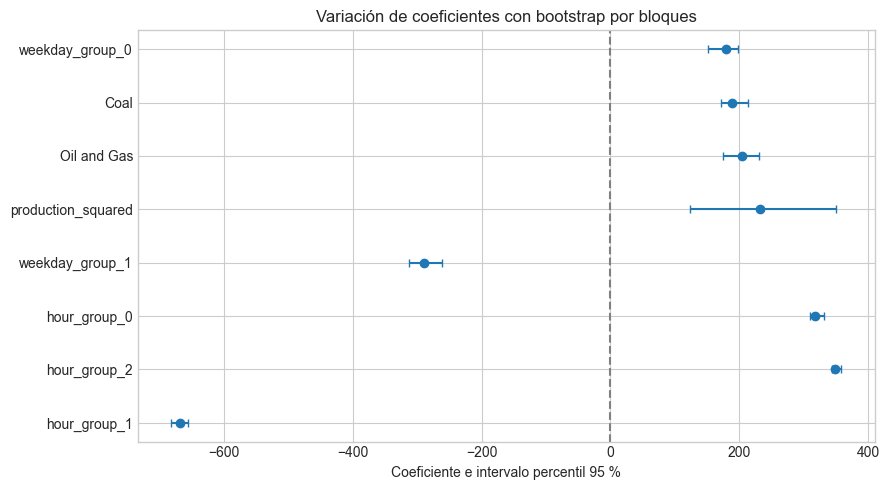

In [128]:
fig, ax = plt.subplots(figsize=(9,5))
positions = np.arange(len(intervals))
ax.errorbar(intervals['mediana'], positions,
            xerr=[intervals['mediana']-intervals['p2.5'], intervals['p97.5']-intervals['mediana']],
            fmt='o', capsize=3)
ax.axvline(0,color='gray',linestyle='--')
ax.set(yticks=positions, yticklabels=intervals.index, xlabel='Coeficiente e intervalo percentil 95 %', title='Variación de coeficientes con bootstrap por bloques')
plt.tight_layout();plt.show()


**Lectura:** intervalos anchos o que cruzan cero muestran sensibilidad de las pendientes al remuestreo. Con predictores correlacionados, el signo de una pendiente puede variar aunque el error predictivo permanezca bajo.

## 11. Evaluación final frente a referencias

Calculamos MAE (error absoluto medio), RMSE (penaliza más errores grandes) y $R^2$ (comparación con media del propio conjunto). La configuración quedó fijada antes de mirar test. Una prueba en un único período no estima toda la variabilidad futura.

In [129]:
predictions = {
    'Baseline': (baseline.predict(X_val), baseline.predict(X_test)),
    'OLS': (ols.predict(X_val), ols.predict(X_test)),
    'Regresión lineal': (final_model.predict(X_val[chosen_features]), final_model.predict(X_test[chosen_features])),
}
rows = []
for model_name, (pv, pt) in predictions.items():
    for split_name, true, predicted in [('validation',y_val,pv),('test',y_test,pt)]:
        rows.append({'modelo':model_name,'partición':split_name,
                     'MAE':mean_absolute_error(true,predicted),
                     'RMSE':np.sqrt(mean_squared_error(true,predicted)),
                     'R2':r2_score(true,predicted)})
metrics = pd.DataFrame(rows)
display(metrics.round(3))


,modelo,partición,MAE,RMSE,R2
0,Baseline,validation,893.964,1063.878,-0.128
1,Baseline,test,967.800,1161.100,-0.130
2,OLS,validation,589.780,732.609,0.465
3,OLS,test,670.878,812.510,0.447
4,Regresión lineal,validation,584.653,721.815,0.481
5,Regresión lineal,test,669.818,820.312,0.436


## 12. Diagnóstico gráfico en test

La curva temporal identifica cambios de régimen; el gráfico real frente a predicho expone sesgo; residuos frente a predicción revela errores sistemáticos. Los residuos próximos en el tiempo pueden estar autocorrelacionados, por lo que una nube aproximadamente simétrica no valida independencia.

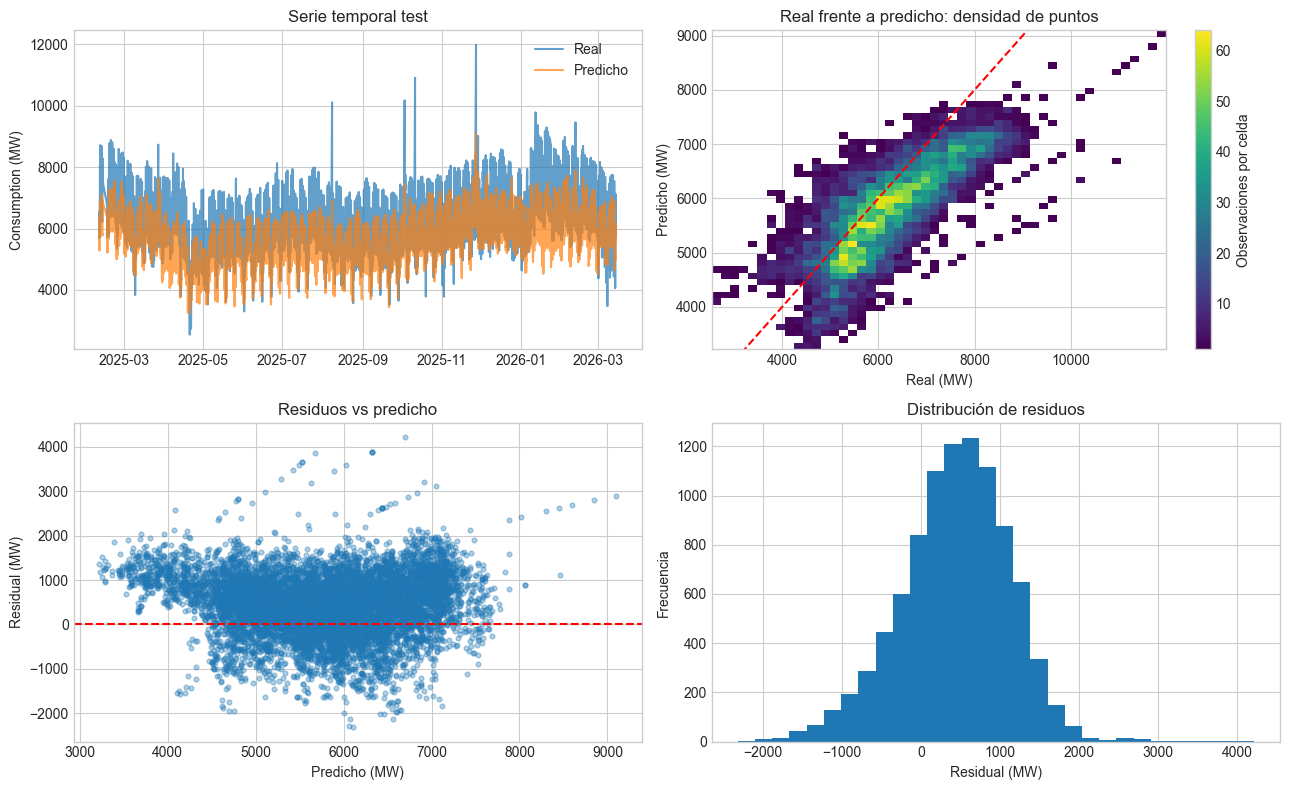

In [133]:
test_prediction = final_model.predict(X_test[chosen_features])
residuals = y_test.to_numpy() - test_prediction
fig, axes = plt.subplots(2,2,figsize=(13,8))
axes[0,0].plot(y_test.index, y_test.to_numpy(),label='Real',alpha=.7)
axes[0,0].plot(y_test.index, test_prediction,label='Predicho',alpha=.7)
axes[0,0].set(title='Serie temporal test', ylabel='Consumption (MW)');axes[0,0].legend()
lo,hi=min(y_test.min(),test_prediction.min()),max(y_test.max(),test_prediction.max())
cloud = axes[0,1].hist2d(y_test, test_prediction, bins=50, cmap='viridis', cmin=1)
fig.colorbar(cloud[3], ax=axes[0,1], label='Observaciones por celda')
axes[0,1].plot([lo,hi],[lo,hi],color='red',linestyle='--')
axes[0,1].set(title='Real frente a predicho: densidad de puntos',xlabel='Real (MW)',ylabel='Predicho (MW)')
axes[1,0].scatter(test_prediction,residuals,alpha=.35,s=12)
axes[1,0].axhline(0,color='red',linestyle='--')
axes[1,0].set(title='Residuos vs predicho',xlabel='Predicho (MW)',ylabel='Residual (MW)')
axes[1,1].hist(residuals,bins=30)
axes[1,1].set(title='Distribución de residuos',xlabel='Residual (MW)',ylabel='Frecuencia')
plt.tight_layout();plt.show()

## 13. Diagnósticos de supuestos en train

VIF resume redundancia lineal de predictores; Breusch–Pagan contrasta varianza constante de errores y Jarque–Bera simetría/curtosis normales. Se calculan con numpy y scipy sobre entrenamiento; VIF usa una muestra para limitar el costo. Breusch–Pagan aquí regresa errores cuadrados sobre el valor ajustado, por lo que examina una forma concreta de heterocedasticidad. En series temporales, también revisamos autocorrelación: p pequeños señalan evidencia contra el supuesto respectivo, no causalidad.

In [131]:
from scipy.stats import chi2, jarque_bera
sample_idx = np.linspace(0, len(X_train)-1, min(len(X_train), 1500), dtype=int)
X_diag = X_train.iloc[sample_idx][ENERGY_FEATURES].to_numpy(dtype=float)
vif_rows = []
for j, feature in enumerate(ENERGY_FEATURES):
    other = np.delete(X_diag, j, axis=1)
    design = np.column_stack([np.ones(len(other)), other])
    fitted = design @ np.linalg.lstsq(design, X_diag[:, j], rcond=None)[0]
    denominator = np.sum((X_diag[:, j] - X_diag[:, j].mean())**2)
    r2_aux = 1 - np.sum((X_diag[:, j] - fitted)**2) / denominator
    vif_rows.append({'feature': feature, 'VIF': 1/(1-r2_aux) if r2_aux < 1 else np.inf})
display(pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).round(2))
train_fitted = final_model.predict(X_train[chosen_features])
train_residual = y_train.to_numpy() - train_fitted
variance_design = np.column_stack([np.ones(len(train_fitted)), train_fitted])
squared = train_residual**2
variance_fit = variance_design @ np.linalg.lstsq(variance_design, squared, rcond=None)[0]
r2_variance = 1 - np.sum((squared-variance_fit)**2)/np.sum((squared-squared.mean())**2)
bp_pvalue = chi2.sf(len(squared)*max(r2_variance, 0), df=1)
jb = jarque_bera(train_residual)
lag_max = min(24, max(1, len(train_residual)//5))
centered = train_residual-train_residual.mean()
rho = [np.dot(centered[k:], centered[:-k])/np.dot(centered,centered) for k in range(1,lag_max+1)]
q_stat = len(centered)*(len(centered)+2)*sum(rho[k-1]**2/(len(centered)-k) for k in range(1,lag_max+1))
ljung_pvalue = chi2.sf(q_stat, df=lag_max)
print('p Breusch–Pagan:', round(bp_pvalue,4), 'p Jarque–Bera:', round(jb.pvalue,4))
print(f'p Ljung–Box (lag {lag_max}):', round(ljung_pvalue,4))


,feature,VIF
0,Production,1660.50
3,Hydroelectric,858.66
2,Wind,761.70
4,Oil and Gas,320.23
5,Coal,172.91
1,Nuclear,98.78
6,Solar,88.08
7,Biomass,1.62


p Breusch–Pagan: 0.0 p Jarque–Bera: 0.0
p Ljung–Box (lag 24): 0.0


**Lectura:** VIF alto afecta estabilidad de coeficientes, no necesariamente precisión predictiva. La prueba de Breusch–Pagan aquí usa valores ajustados como regresor de varianza y solo detecta esa clase de patrón; Jarque–Bera y Ljung–Box también dependen de tamaño de muestra y especificación. Los intervalos de coeficientes clásicos no son fiables automáticamente si hay autocorrelación.

## Limitaciones y conclusiones

Usa la tabla calculada para comparar baseline, OLS y el modelo final en validation/test. Interpreta si los errores cambian con el tiempo y si los coeficientes permanecen razonables. **Production y sus fuentes pueden contener información contemporánea del objetivo:** las métricas de este laboratorio corresponden a estimación con esas variables disponibles; para forecast real hay que construir rezagos y validar horizontes futuros. Un cambio de régimen o despliegue en otra población puede alterar los resultados. El término cuadrático, la proporción renovable y las categorías agrupadas son hipótesis que requieren ablation por feature y repetición temporal; los niveles de grupo no observados en entrenamiento se codifican como desconocidos y deben evaluarse en ventanas futuras. La regularización controla complejidad, no corrige por sí sola confusión ni dependencia temporal.

Los grupos supervisados se derivan de medias y desviaciones históricas; su número, estabilidad y cobertura de categorías futuras deben revisarse. La etiqueta `-1` indica un nivel nuevo o poco observado, no un segmento de consumo inferido.


## Ejercicios sin solución

1. Elimina `Production` y compara el error y la estabilidad de coeficientes.
2. Contrasta el error por hora y por mes usando solo el período de test.
3. Construye rezagos disponibles al predecir y reevalúa con horizonte definido.
4. Compara al menos dos esquemas de validación temporal sin mezclar fechas futuras.
5. Explica por qué una variable correlacionada puede cambiar de signo al agregar otras.


## Fuente

`electricity_consumption_and_production.csv`, archivo externo utilizado en los cuatro notebooks originales. Se requiere disponer del dataset del curso; sin él no pueden verificarse resultados numéricos reales.
